In [1]:
!pip install transformers datasets scikit-learn

In [9]:
from transformers import TrainingArguments, Trainer

In [2]:
from datasets import load_dataset

dataset = load_dataset("ag_news")

def convert_label(example):
    example["label"] = 0 if example["label"] <= 1 else 1
    return example

dataset = dataset.map(convert_label)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

In [10]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import TrainingArguments, Trainer

In [4]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)

tokenized_dataset = tokenized_dataset.remove_columns(["text"])
tokenized_dataset = tokenized_dataset.rename_column("label", "labels")
tokenized_dataset.set_format("torch")

train_dataset = tokenized_dataset["train"]
test_dataset = tokenized_dataset["test"]

In [5]:
train_dataset = train_dataset.shuffle(seed=42).select(range(10000))
test_dataset = test_dataset.shuffle(seed=42).select(range(1000))

print(len(train_dataset))
print(len(test_dataset))

10000
1000


In [6]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [7]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average="binary"
    )
    acc = accuracy_score(labels, predictions)
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [11]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16
)

In [12]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

In [13]:
trainer.train()

Step,Training Loss
500,0.170451
1000,0.094628


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1250, training_loss=0.1199303482055664, metrics={'train_runtime': 259.2577, 'train_samples_per_second': 77.143, 'train_steps_per_second': 4.821, 'total_flos': 662336993280000.0, 'train_loss': 0.1199303482055664, 'epoch': 2.0})

In [19]:
trainer.evaluate()

{'eval_loss': 0.12617161870002747,
 'eval_accuracy': 0.964,
 'eval_precision': 0.9466403162055336,
 'eval_recall': 0.9815573770491803,
 'eval_f1': 0.9637826961770624,
 'eval_runtime': 3.8565,
 'eval_samples_per_second': 259.3,
 'eval_steps_per_second': 16.336,
 'epoch': 2.0}

In [20]:
predictions = trainer.predict(test_dataset)
preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

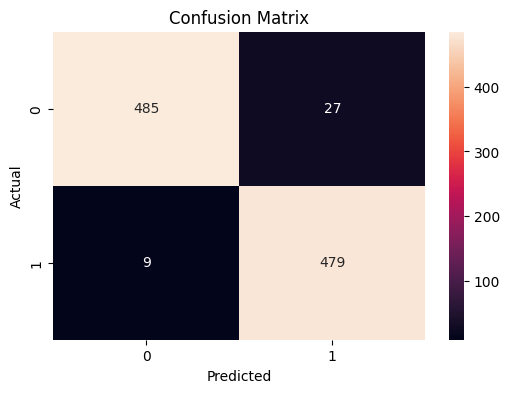

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [22]:
trainer.save_model("./fake_news_model")
tokenizer.save_pretrained("./fake_news_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./fake_news_model/tokenizer_config.json', './fake_news_model/tokenizer.json')

In [26]:
import shutil
shutil.make_archive("fake_news_model", 'zip', "./fake_news_model")

'/content/fake_news_model.zip'

In [24]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def predict_text(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # MOVE INPUTS TO GPU
    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=1)

    return "Fake" if prediction.item() == 0 else "Real"

In [25]:
predict_text("Breaking news: Government announces new technology investment")

'Real'